# 06 - Figures for the Deck

Every chart in the presentation comes from here: the thirteen figures restyled from notebooks 04
and 05's saved artefacts, plus four more built around the macro overlay. Nothing gets recomputed:
this reads `Output/*.parquet` and `Output/*.xlsx` and writes `figures/*.png` at dpi 200.

Two figures need a quick refit since fitted estimators aren't serialised: the entropy tree and the
forest with macro. Both get checked against the published out-of-time AUC before anything is drawn
from them.

## 1. Setup

The navy/green system used everywhere in the deck: validated colour ramp in slot order, top and
right spines gone, y-grid only and behind the marks, zero-length grey ticks, direct labels on the
mark that carries the finding rather than a legend.

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings('ignore')

SEED = 42

BASE = pathlib.Path.cwd()
DIR_OUT = BASE / 'Output'
DIR_FIG = BASE / 'figures'
DIR_FIG.mkdir(exist_ok=True)

# Chrome - typography and structure. NOT data colours.
NAVY = '#1B3A4B'
INK = '#1A1A1A'
GREY = '#6E7A85'
GREY_LINE = '#D8DCE0'
GREY_FILL = '#F2F3F4'
WHITE = '#FFFFFF'
GREEN = '#00843D'
GREEN_MID = '#4A9B6E'
GREEN_TINT = '#F1F8F3'

# Data - validated categorical ramp, assigned in this fixed order, never cycled.
S1 = '#2E9B57'   # slot 1, green
S2 = '#2C6EA9'   # slot 2, blue
S3 = '#C77F2E'   # slot 3, amber

# Status - reserved, never a series colour, always shipped with a text label.
GOOD = '#2E9B57'
WARN = '#C77F2E'
CRIT = '#B5562D'

BLUE_TINT = '#EAF1F8'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 10,
    'figure.facecolor': WHITE,
    'axes.facecolor': WHITE,
    'savefig.facecolor': WHITE,
    'text.color': INK,
    'axes.labelcolor': GREY,
    'axes.labelsize': 10,
    'axes.edgecolor': GREY_LINE,
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': GREY_LINE,
    'grid.linewidth': 0.6,
    'grid.alpha': 0.7,
    'xtick.color': GREY,
    'ytick.color': GREY,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'legend.frameon': False,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'figure.dpi': 100,
})


def style(ax, *, ygrid=True, xgrid=False):
    """Despine, y-grid only, zero-length grey ticks."""
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(GREY_LINE)
        ax.spines[side].set_linewidth(0.8)
    ax.set_axisbelow(True)
    ax.grid(False)
    if ygrid:
        ax.grid(axis='y', color=GREY_LINE, lw=0.6, alpha=0.7)
    if xgrid:
        ax.grid(axis='x', color=GREY_LINE, lw=0.6, alpha=0.7)
    ax.tick_params(length=0, colors=GREY, labelsize=9)
    return ax


def save(fig, name):
    """Save to figures/<name>.png at dpi 200, show it inline, then close it."""
    path = DIR_FIG / f'{name}.png'
    fig.savefig(path, dpi=200)
    plt.show()
    plt.close(fig)
    print(f'saved {path.name}')


print(f'working directory: {BASE}')

working directory: C:\Github_offline\Credit Risk Modelling\Final_Handover


## 2. Data

Straight from `Output/`: nothing here re-runs notebook 04 or 05. The row counts are asserted so a
stale `df_woe.parquet` fails loudly instead of quietly drawing the wrong panel.

In [2]:
scores = pd.read_parquet(DIR_OUT / 'df_scores.parquet')
oot_s = scores[scores['sample'] == 'oot'].copy()

mc = pd.ExcelFile(DIR_OUT / 'model_comparison.xlsx')
metrics = mc.parse('metrics').set_index('model')
boot = mc.parse('bootstrap').set_index('comparison')
macro_boot = mc.parse('macro_bootstrap').set_index('comparison')
placebo = mc.parse('placebo')['placebo_gain'].to_numpy()

rt = pd.ExcelFile(DIR_OUT / 'ratings.xlsx')
course_scale = rt.parse('course_scale')
calib_scale = rt.parse('calibrated_scale')
transition = rt.parse('transition_202212_202312').set_index('grade 202212')
calib_oot = rt.parse('calibration_oot')

ps = pd.ExcelFile(DIR_OUT / 'psi.xlsx')
psi_year = ps.parse('psi_by_year')

FEATURES = ['A01_woe', 'M01_woe', 'E01_woe', 'L01_woe']
woe = pd.read_parquet(
    DIR_OUT / 'df_woe.parquet',
    columns=['ID', 'DATA', 'sample', 'target', 'y_adj', 'A01', 'M01', 'E01', 'L01'] + FEATURES,
)
lab = woe[woe['target'].notna()].copy()
lab['y_adj'] = lab['y_adj'].astype(int)
train_w = lab[lab['sample'] == 'train'].copy()
oot_w = lab[lab['sample'] == 'oot'].copy()
assert len(train_w) == 7975 and len(oot_w) == 1737, (len(train_w), len(oot_w))

# the diagnostic frame the two data-quality figures need: scores plus the raw ratios and WoE bins
diag = scores.merge(woe.drop(columns=['sample', 'target', 'y_adj']), on=['ID', 'DATA'],
                    how='left', validate='one_to_one')
diag['year'] = diag['DATA'] // 100
diag['month'] = diag['DATA'] % 100

LOGIT_OOT = float(metrics.loc['Logit (WoE)', 'oot_AUC'])
FOREST_OOT = float(metrics.loc['Forest d=4', 'oot_AUC'])
TREE_OOT = float(metrics.loc['Tree entropy d=3', 'oot_AUC'])

## 3. Core figures

### `04_roc_oot` - ROC, out-of-time

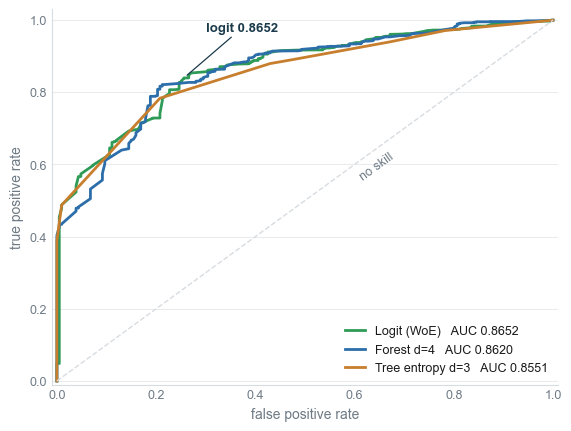

saved 04_roc_oot.png


In [3]:
fig, ax = plt.subplots(figsize=(5.6, 4.2), layout='constrained')
series = [('Logit (WoE)', 'score_logit', S1, LOGIT_OOT),
          ('Forest d=4', 'score_forest', S2, FOREST_OOT),
          ('Tree entropy d=3', 'score_tree', S3, TREE_OOT)]
for name, col, colour, auc in series:
    fpr, tpr, _ = roc_curve(oot_s['y_adj'], oot_s[col])
    ax.plot(fpr, tpr, color=colour, lw=2.0, label=f'{name}   AUC {auc:.4f}')
ax.plot([0, 1], [0, 1], color=GREY_LINE, ls='--', lw=1.0)
ax.text(0.62, 0.55, 'no skill', color=GREY, fontsize=9, rotation=36,
        rotation_mode='anchor', ha='left', va='bottom')

fpr, tpr, _ = roc_curve(oot_s['y_adj'], oot_s['score_logit'])
i = int(np.argmax(tpr - fpr))
ax.annotate(f'logit {LOGIT_OOT:.4f}', xy=(fpr[i], tpr[i]), xytext=(0.30, 0.995),
            color=NAVY, fontsize=9.5, fontweight='bold', ha='left', va='top',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9,
                            shrinkA=0, shrinkB=3))
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.03)
ax.legend(loc='lower right', handlelength=1.6, borderaxespad=0.4)
style(ax)
save(fig, '04_roc_oot')

### `04_overfitting` - AUC across model capacity

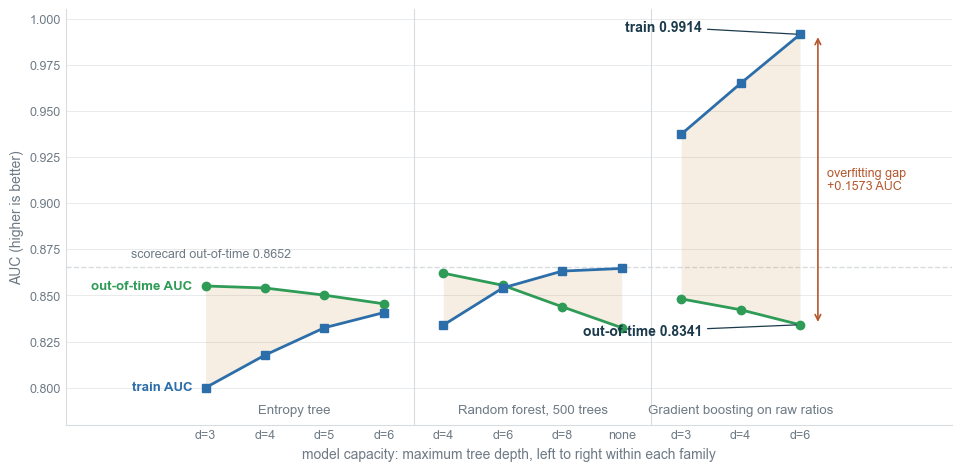

saved 04_overfitting.png


In [4]:
rows = ['Tree entropy d=3', 'Tree entropy d=4', 'Tree entropy d=5', 'Tree entropy d=6',
        'Forest d=4', 'Forest d=6', 'Forest d=8', 'Forest d=None',
        'HistGradientBoosting raw d=3', 'HistGradientBoosting raw d=4',
        'HistGradientBoosting raw d=6']
ticks = ['d=3', 'd=4', 'd=5', 'd=6', 'd=4', 'd=6', 'd=8', 'none', 'd=3', 'd=4', 'd=6']
groups = [(0, 3, 'Entropy tree'), (4, 7, 'Random forest, 500 trees'),
          (8, 10, 'Gradient boosting on raw ratios')]
tr = metrics.loc[rows, 'train_AUC'].to_numpy()
ot = metrics.loc[rows, 'oot_AUC'].to_numpy()
x = np.arange(len(rows))

fig, ax = plt.subplots(figsize=(9.5, 4.6), layout='constrained')
for a, b, _ in groups:
    sl = slice(a, b + 1)
    ax.fill_between(x[sl], ot[sl], tr[sl], color=WARN, alpha=0.13, lw=0, zorder=1)
    ax.plot(x[sl], ot[sl], color=S1, lw=2.0, marker='o', ms=6, zorder=3)
    ax.plot(x[sl], tr[sl], color=S2, lw=2.0, marker='s', ms=6, zorder=3)

ax.axhline(LOGIT_OOT, color=GREY_LINE, ls='--', lw=1.0, zorder=0)
ax.text(-1.25, LOGIT_OOT + 0.004, f'scorecard out-of-time {LOGIT_OOT:.4f}',
        color=GREY, fontsize=9, va='bottom')

for a, b, label in groups[1:]:
    ax.axvline(a - 0.5, color=GREY_LINE, lw=0.8, zorder=0)
for a, b, label in groups:
    ax.text((a + b) / 2, 0.7845, label, color=GREY, fontsize=9.5, ha='center', va='bottom')

# direct labels at the left end of each series, the right end carries the finding
ax.text(-0.22, ot[0], 'out-of-time AUC', color=S1, fontsize=9.5, fontweight='bold',
        ha='right', va='center')
ax.text(-0.22, tr[0], 'train AUC', color=S2, fontsize=9.5, fontweight='bold',
        ha='right', va='center')

# the finding: the boosting extreme
ax.annotate(f'train {tr[-1]:.4f}', xy=(x[-1], tr[-1]), xytext=(x[-1] - 1.65, 0.9955),
            color=NAVY, fontsize=10, fontweight='bold', ha='right', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=3))
ax.annotate(f'out-of-time {ot[-1]:.4f}', xy=(x[-1], ot[-1]), xytext=(x[-1] - 1.65, 0.8305),
            color=NAVY, fontsize=10, fontweight='bold', ha='right', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=3))
ax.annotate('', xy=(x[-1] + 0.30, tr[-1]), xytext=(x[-1] + 0.30, ot[-1]),
            arrowprops=dict(arrowstyle='<->', color=CRIT, lw=1.2))
ax.text(x[-1] + 0.45, (tr[-1] + ot[-1]) / 2,
        f'overfitting gap\n{tr[-1] - ot[-1]:+.4f} AUC', color=CRIT, fontsize=9,
        ha='left', va='center')

ax.set_xticks(x)
ax.set_xticklabels(ticks)
ax.set_xlim(-2.35, len(rows) + 1.55)
ax.set_ylim(0.78, 1.005)
ax.set_xlabel('model capacity: maximum tree depth, left to right within each family')
ax.set_ylabel('AUC (higher is better)')
style(ax)
save(fig, '04_overfitting')

### `04_bootstrap_dauc` - cluster bootstrap on the AUC differences

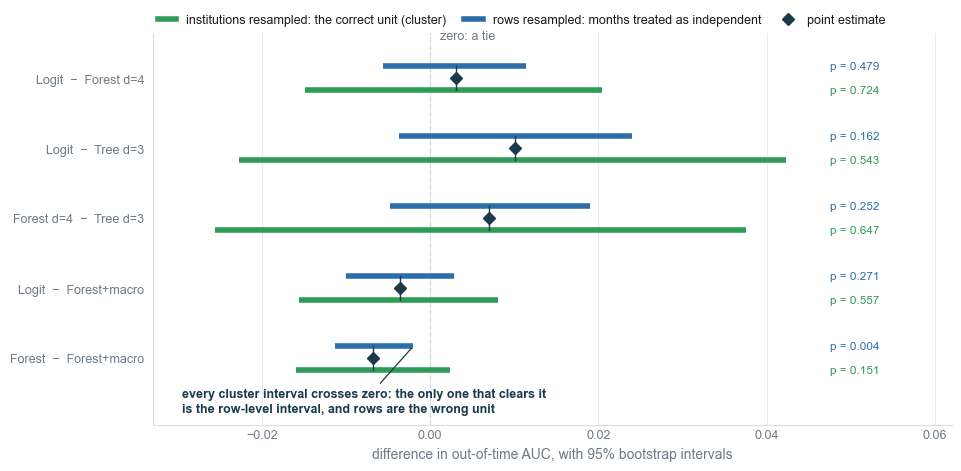

saved 04_bootstrap_dauc.png


In [5]:
table = pd.concat([boot, macro_boot])
labels = ['Logit - Forest d=4', 'Logit - Tree d=3', 'Forest d=4 - Tree d=3',
          'Logit - Forest+macro', 'Forest - Forest+macro']
pretty = [s.replace(' - ', '  \u2212  ') for s in labels]
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(9.5, 4.6), layout='constrained')
off = 0.17
for yi, key in zip(y, labels):
    r = table.loc[key]
    ax.plot([r['cluster_ci_low'], r['cluster_ci_high']], [yi - off, yi - off],
            color=S1, lw=4.0, solid_capstyle='butt', zorder=3)
    ax.plot([r['row_ci_low'], r['row_ci_high']], [yi + off, yi + off],
            color=S2, lw=4.0, solid_capstyle='butt', zorder=3)
    ax.plot([r['dAUC'], r['dAUC']], [yi - off, yi + off], color=NAVY, lw=1.0, zorder=5)
    ax.plot([r['dAUC']], [yi], marker='D', ms=6, color=NAVY, zorder=6)
    ax.text(0.0475, yi + off, f"p = {r['row_p']:.3f}", color=S2, fontsize=8.5,
            va='center', ha='left')
    ax.text(0.0475, yi - off, f"p = {r['cluster_p']:.3f}", color=S1, fontsize=8.5,
            va='center', ha='left')

ax.axvline(0, color=GREY_LINE, ls='--', lw=1.0, zorder=1)
ax.text(0.0012, y[0] + 0.52, 'zero: a tie', color=GREY, fontsize=9, va='bottom')

# the one row-level "significant" result, and what clustering does to it
r = table.loc['Forest - Forest+macro']
ax.annotate('every cluster interval crosses zero: the only one that clears it\n'
            'is the row-level interval, and rows are the wrong unit',
            xy=(r['row_ci_high'], y[-1] + off), xytext=(-0.0295, y[-1] - 0.62),
            color=NAVY, fontsize=9, fontweight='bold', ha='left', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=2))

ax.plot([], [], color=S1, lw=4.0, label='institutions resampled: the correct unit (cluster)')
ax.plot([], [], color=S2, lw=4.0, label='rows resampled: months treated as independent')
ax.plot([], [], marker='D', ms=6, color=NAVY, lw=0, label='point estimate')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.06), ncols=3, handlelength=1.5,
          columnspacing=1.4, borderaxespad=0.0)

ax.set_yticks(y)
ax.set_yticklabels(pretty, fontsize=9.5)
ax.set_ylim(-0.95, len(labels) - 0.35)
ax.set_xlim(-0.033, 0.062)
ax.set_xlabel('difference in out-of-time AUC, with 95% bootstrap intervals')
style(ax, ygrid=False, xgrid=True)
ax.tick_params(axis='y', pad=6)
save(fig, '04_bootstrap_dauc')

### `04_placebo` - placebo test for the macro gain

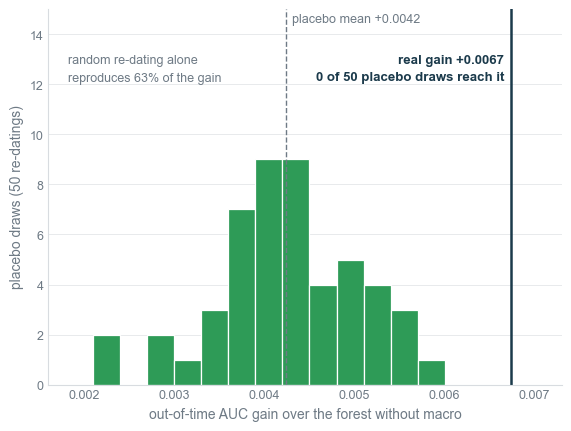

saved 04_placebo.png


In [6]:
real = -float(macro_boot.loc['Forest - Forest+macro', 'dAUC'])
mean = placebo.mean()

fig, ax = plt.subplots(figsize=(5.6, 4.2), layout='constrained')
bins = np.linspace(0.0018, 0.0063, 16)
ax.hist(placebo, bins=bins, color=S1, edgecolor=WHITE, lw=0.9)
top = 15.0
ax.set_ylim(0, top)

ax.axvline(mean, color=GREY, ls='--', lw=1.0)
ax.text(mean + 0.00006, top * 0.99, f'placebo mean {mean:+.4f}', color=GREY, fontsize=9,
        ha='left', va='top')
ax.axvline(real, color=NAVY, lw=1.8)
ax.text(real - 0.00008, top * 0.88,
        f'real gain {real:+.4f}\n0 of {placebo.size} placebo draws reach it',
        color=NAVY, fontsize=9.5, fontweight='bold', ha='right', va='top',
        linespacing=1.5)
ax.text(0.00182, top * 0.88,
        f'random re-dating alone\nreproduces {mean / real:.0%} of the gain',
        color=GREY, fontsize=9, va='top', ha='left', linespacing=1.5)

ax.set_xlabel('out-of-time AUC gain over the forest without macro')
ax.set_ylabel('placebo draws (50 re-datings)')
ax.set_xlim(0.0016, 0.0073)
style(ax)
save(fig, '04_placebo')

### `04_tree_depth3` - entropy tree, depth 3 (refit)

Notebook 04's own tree isn't serialised, so this refits it on `train` with the same
hyperparameters and seed.

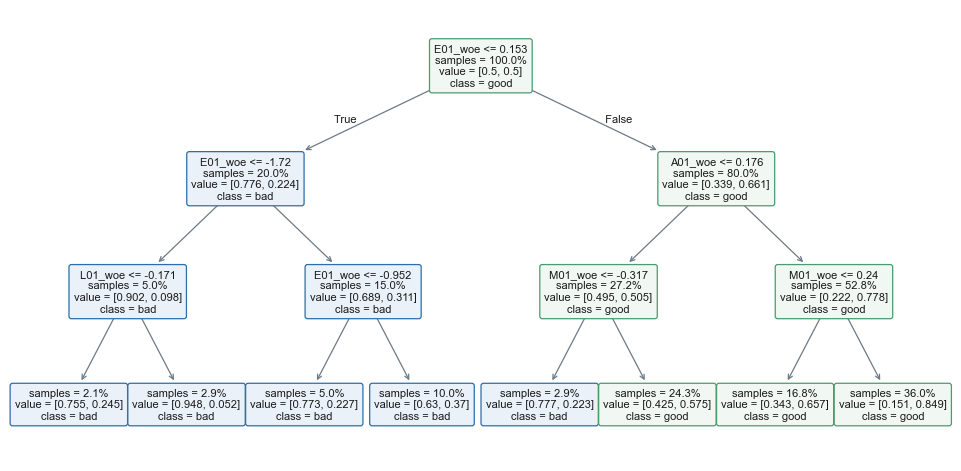

saved 04_tree_depth3.png


In [7]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=50,
                             class_weight='balanced', random_state=SEED)
clf.fit(train_w[FEATURES], train_w['y_adj'])

fig, ax = plt.subplots(figsize=(9.5, 4.6), layout='constrained')
annotations = plot_tree(clf, feature_names=FEATURES, class_names=['bad', 'good'],
                        filled=True, rounded=True, impurity=False, proportion=True,
                        precision=3, fontsize=8, ax=ax)
fig.canvas.draw()
for a in annotations:
    patch = a.get_bbox_patch()
    if patch is None:
        continue
    good = 'class = good' in a.get_text()
    patch.set_facecolor(GREEN_TINT if good else BLUE_TINT)
    patch.set_edgecolor(GREEN_MID if good else S2)
    patch.set_linewidth(0.9)
    patch.set_boxstyle('round', pad=0.42, rounding_size=0.22)
    a.set_color(INK)
    if a.arrow_patch is not None:
        a.arrow_patch.set_color(GREY)
        a.arrow_patch.set_linewidth(0.9)
for t in ax.texts:
    if t.get_text() in ('True', 'False'):
        t.set_color(GREY)
ax.set_axis_off()
ax.grid(False)
save(fig, '04_tree_depth3')

### `04_shap_beeswarm` - SHAP, forest depth 4 (refit)

Same reason as the tree: refit on `train`, seed 42, explained with `TreeExplainer` on an 800-row
`oot` sample.

mean |SHAP| : E01_woe 0.1618, A01_woe 0.0696, M01_woe 0.0457, L01_woe 0.0420


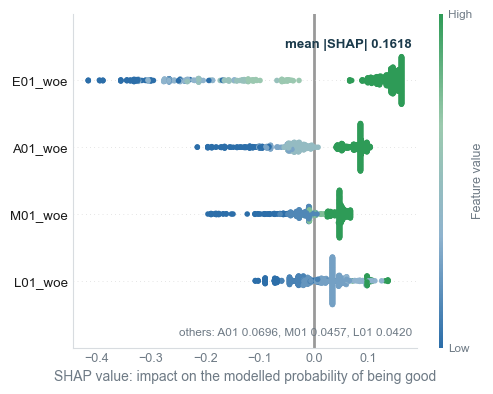

saved 04_shap_beeswarm.png


In [8]:
import shap

rf = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=20,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(train_w[FEATURES], train_w['y_adj'])

sample = oot_w[FEATURES].sample(n=800, random_state=SEED)
explainer = shap.TreeExplainer(rf)
sv = explainer(sample, check_additivity=False)[..., 1]
mean_abs = pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print('mean |SHAP| :', ', '.join(f'{k} {v:.4f}' for k, v in mean_abs.items()))

cmap = LinearSegmentedColormap.from_list('cr_blue_green', [S2, '#8FB3CE', '#9CCAAE', S1])
fig = plt.figure(figsize=(5.9, 4.2))
shap.plots.beeswarm(sv, show=False, color=cmap, color_bar=True, plot_size=None)
ax = plt.gca()
ax.set_title('')
ax.set_xlabel('SHAP value: impact on the modelled probability of being good', fontsize=10,
              color=GREY)
ax.set_ylabel('')
style(ax, ygrid=False)
ax.grid(False)
ax.tick_params(axis='y', labelsize=9.5, colors=INK, length=0)

top = mean_abs.index[0]
ylab = [t.get_text() for t in ax.get_yticklabels()]
y_top = ax.get_yticks()[ylab.index(top)]
ax.text(0.985, y_top + 0.54, f'mean |SHAP| {mean_abs.iloc[0]:.4f}',
        transform=ax.get_yaxis_transform(),
        color=NAVY, fontsize=9.5, fontweight='bold', ha='right', va='center')
ax.text(0.985, 0.045,
        'others: ' + ', '.join(f'{k.split("_")[0]} {v:.4f}' for k, v in mean_abs[1:].items()),
        transform=ax.transAxes, color=GREY, fontsize=8.5, ha='right', va='center')
for cb_ax in fig.axes[1:]:
    cb_ax.tick_params(length=0, colors=GREY, labelsize=8.5)
    for spine in cb_ax.spines.values():
        spine.set_visible(False)
    cb_ax.set_ylabel(cb_ax.get_ylabel(), color=GREY, fontsize=9)
fig.subplots_adjust(left=0.17, right=0.90, top=0.97, bottom=0.175)
save(fig, '04_shap_beeswarm')
assert top == 'E01_woe', top

### `05_roc_ks_oot` - ROC and KS side by side

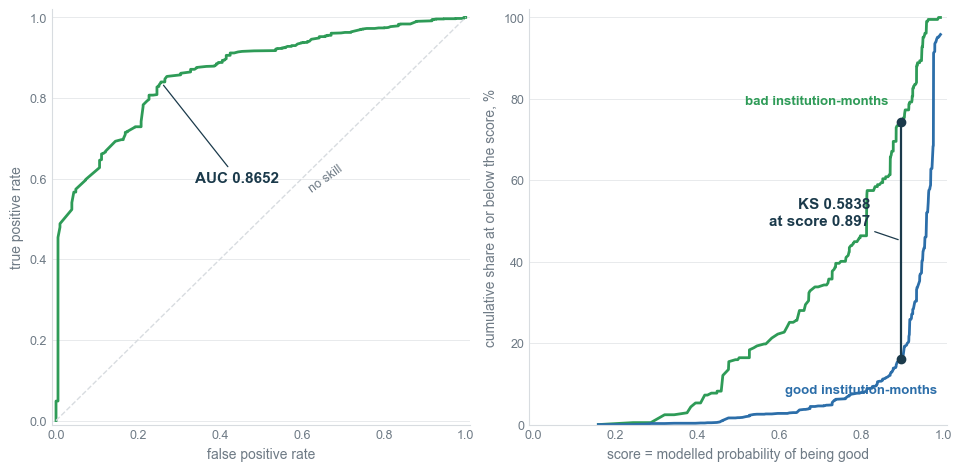

saved 05_roc_ks_oot.png


In [9]:
y = oot_s['y_adj'].to_numpy()
s = oot_s['score_logit'].to_numpy()
fpr, tpr, thr = roc_curve(y, s)
i = int(np.argmax(tpr - fpr))
ks = float((tpr - fpr)[i])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), layout='constrained')

ax = axes[0]
ax.plot(fpr, tpr, color=S1, lw=2.0)
ax.plot([0, 1], [0, 1], color=GREY_LINE, ls='--', lw=1.0)
ax.text(0.63, 0.56, 'no skill', color=GREY, fontsize=9, rotation=36,
        rotation_mode='anchor', ha='left', va='bottom')
ax.annotate(f'AUC {LOGIT_OOT:.4f}', xy=(fpr[i], tpr[i]), xytext=(0.34, 0.60),
            color=NAVY, fontsize=11, fontweight='bold', ha='left', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=3))
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.02)
style(ax)

ax = axes[1]
# cumulative share at or below a score, bads first since slot 1 carries the finding
ax.plot(thr[1:], (1 - fpr)[1:] * 100, color=S1, lw=2.0)
ax.plot(thr[1:], (1 - tpr)[1:] * 100, color=S2, lw=2.0)
ax.text(thr[i] - 0.03, (1 - fpr)[i] * 100 + 3.5, 'bad institution-months',
        color=S1, fontsize=9.5, fontweight='bold', ha='right', va='bottom')
ax.text(0.615, 7.0, 'good institution-months',
        color=S2, fontsize=9.5, fontweight='bold', ha='left', va='bottom')
ax.plot([thr[i], thr[i]], [(1 - tpr)[i] * 100, (1 - fpr)[i] * 100], color=NAVY, lw=1.6)
ax.plot([thr[i]], [(1 - fpr)[i] * 100], marker='o', ms=6, color=NAVY)
ax.plot([thr[i]], [(1 - tpr)[i] * 100], marker='o', ms=6, color=NAVY)
ax.annotate(f'KS {ks:.4f}\nat score {thr[i]:.3f}',
            xy=(thr[i], ((1 - tpr)[i] + (1 - fpr)[i]) * 50),
            xytext=(thr[i] - 0.075, 52), color=NAVY, fontsize=11, fontweight='bold',
            ha='right', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=2))
ax.set_xlabel('score = modelled probability of being good')
ax.set_ylabel('cumulative share at or below the score, %')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(0, 102)
style(ax)
save(fig, '05_roc_ks_oot')

### `05_calibration_oot` - predicted PD vs. observed bad rate

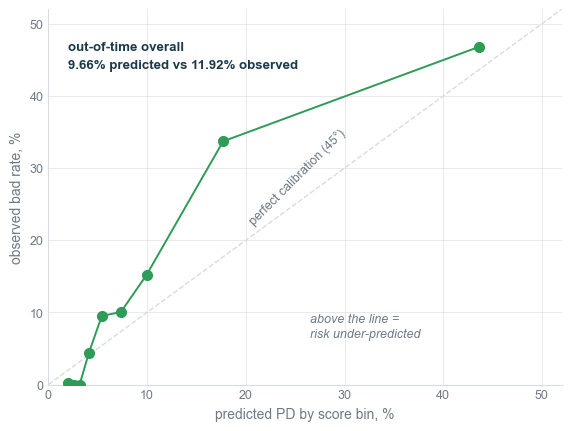

saved 05_calibration_oot.png


In [10]:
p = calib_oot['predicted_PD'].to_numpy() * 100
o = calib_oot['observed'].to_numpy() * 100
pred_all = (1 - oot_s['score_logit']).mean() * 100
obs_all = (1 - oot_s['y_adj'].mean()) * 100

fig, ax = plt.subplots(figsize=(5.6, 4.2), layout='constrained')
lim = 52
ax.plot([0, lim], [0, lim], color=GREY_LINE, ls='--', lw=1.0)
ax.text(21.0, 21.8, 'perfect calibration (45\u00b0)', color=GREY, fontsize=9,
        rotation=45, rotation_mode='anchor', ha='left', va='bottom')
ax.plot(p, o, color=S1, lw=1.4, marker='o', ms=7, zorder=3)
ax.text(2.0, 47.5, f'out-of-time overall\n{pred_all:.2f}% predicted vs {obs_all:.2f}% observed',
        color=NAVY, fontsize=9.5, fontweight='bold', ha='left', va='top', linespacing=1.5)
ax.text(26.5, 8.0, 'above the line =\nrisk under-predicted', color=GREY, fontsize=9,
        style='italic', ha='left', va='center')
ax.set_xlabel('predicted PD by score bin, %')
ax.set_ylabel('observed bad rate, %')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
style(ax)
ax.grid(axis='x', color=GREY_LINE, lw=0.6, alpha=0.7)
save(fig, '05_calibration_oot')

### `05_rating_scale` - the two rating scales side by side

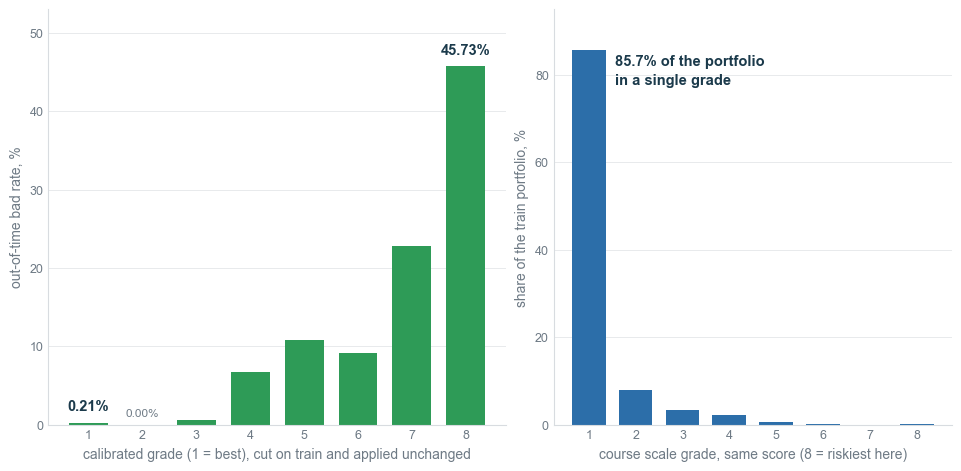

saved 05_rating_scale.png


In [11]:
g = calib_scale['grade (1 = best)'].to_numpy()
bad = calib_scale['oot_bad_%'].to_numpy()
cg = course_scale['course grade'].to_numpy()
share = course_scale['share_%'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), layout='constrained',
                         gridspec_kw={'width_ratios': [1.15, 1.0]})

ax = axes[0]
ax.bar(g, bad, width=0.72, color=S1, lw=0)
for gi, bi in zip(g, bad):
    if gi in (1, 8):
        ax.text(gi, bi + 1.2, f'{bi:.2f}%', color=NAVY, fontsize=10.5, fontweight='bold',
                ha='center', va='bottom')
    elif bi == 0:   # an exact zero, not a missing bar
        ax.text(gi, 0.8, '0.00%', color=GREY, fontsize=8.5, ha='center', va='bottom')
ax.set_xticks(g)
ax.set_xlabel('calibrated grade (1 = best), cut on train and applied unchanged')
ax.set_ylabel('out-of-time bad rate, %')
ax.set_ylim(0, 53)
style(ax)

ax = axes[1]
ax.bar(cg, share, width=0.72, color=S2, lw=0)
ax.text(1.55, share[0] - 1.0, f'{share[0]:.1f}% of the portfolio\nin a single grade',
        color=NAVY, fontsize=10.5, fontweight='bold', ha='left', va='top', linespacing=1.5)
ax.set_xticks(cg)
ax.set_xlabel("course scale grade, same score (8 = riskiest here)")
ax.set_ylabel('share of the train portfolio, %')
ax.set_ylim(0, 95)
style(ax)
save(fig, '05_rating_scale')

### `05_migration` - grade migration, 202212 to 202312

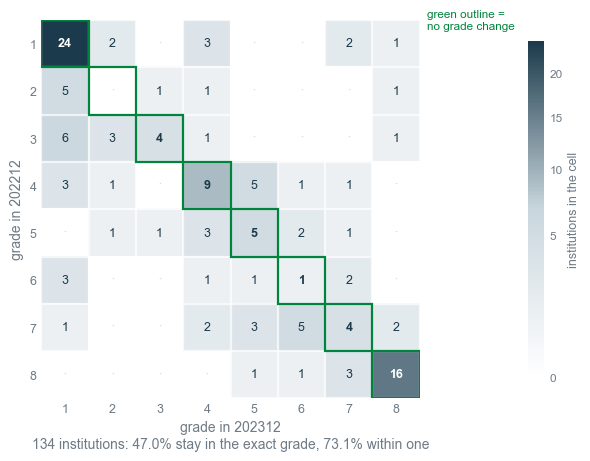

saved 05_migration.png


In [12]:
m = transition.to_numpy(dtype=float)
grades = [int(c) for c in transition.columns]
cmap = LinearSegmentedColormap.from_list('cr_navy_seq', [WHITE, '#C9D6DD', NAVY])

from matplotlib.colors import PowerNorm

norm = PowerNorm(gamma=0.55, vmin=0, vmax=m.max())
fig, ax = plt.subplots(figsize=(5.9, 4.5), layout='constrained')
im = ax.imshow(m, cmap=cmap, norm=norm)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = int(m[i, j])
        if v == 0:
            ax.text(j, i, '\u00b7', color=GREY_LINE, fontsize=11, ha='center', va='center')
            continue
        ax.text(j, i, str(v), fontsize=9,
                color=WHITE if norm(m[i, j]) > 0.62 else NAVY,
                fontweight='bold' if i == j else 'normal', ha='center', va='center')
for i in range(m.shape[0]):
    ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=GREEN,
                           lw=1.6, zorder=4))
ax.set_xticks(range(len(grades)), grades)
ax.set_yticks(range(len(grades)), grades)
ax.set_xlabel('grade in 202312\n134 institutions: 47.0% stay in the exact grade, '
              '73.1% within one')
ax.set_ylabel('grade in 202212')
ax.tick_params(length=0, colors=GREY, labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.set_xticks(np.arange(-0.5, len(grades), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(grades), 1), minor=True)
ax.grid(which='minor', color=WHITE, lw=1.6)
ax.tick_params(which='minor', length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(length=0, colors=GREY, labelsize=8.5)
cb.set_label('institutions in the cell', color=GREY, fontsize=9)
ax.text(1.02, -0.5, 'green outline =\nno grade change', transform=ax.get_yaxis_transform(),
        color=GREEN, fontsize=8.5, ha='left', va='center')
save(fig, '05_migration')

### `05_psi_by_year` - population stability by year

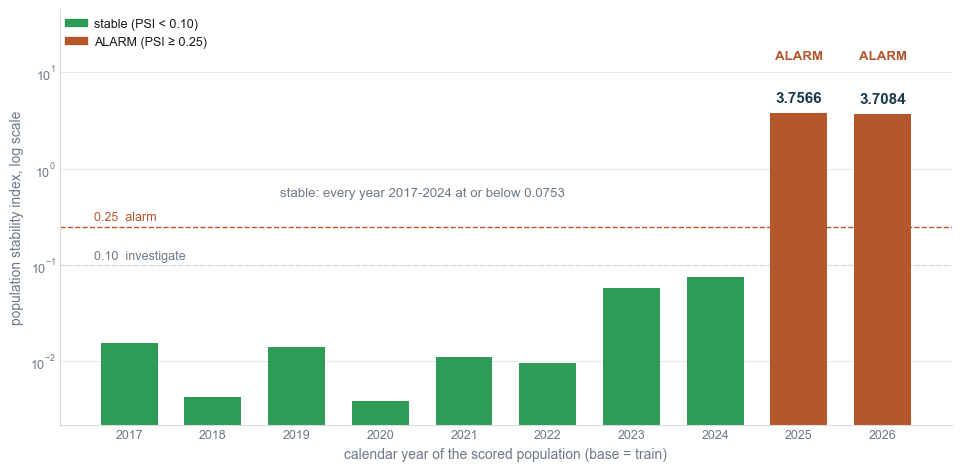

saved 05_psi_by_year.png


In [13]:
yrs = psi_year['year'].to_numpy()
psi = psi_year['PSI'].to_numpy()
alarm = psi >= 0.25
colours = [CRIT if a else GOOD for a in alarm]

fig, ax = plt.subplots(figsize=(9.5, 4.6), layout='constrained')
ax.bar(yrs, psi, width=0.68, color=colours, lw=0)
ax.set_yscale('log')
ax.set_ylim(0.0022, 45)

ax.axhline(0.10, color=GREY_LINE, ls='--', lw=1.0, zorder=0)
ax.text(yrs[0] - 0.42, 0.107, '0.10  investigate', color=GREY, fontsize=9, va='bottom')
ax.axhline(0.25, color=CRIT, ls='--', lw=1.0, zorder=0)
ax.text(yrs[0] - 0.42, 0.268, '0.25  alarm', color=CRIT, fontsize=9, va='bottom')

for yi, pi, a in zip(yrs, psi, alarm):
    if a:
        ax.text(yi, pi * 1.20, f'{pi:.4f}', color=NAVY, fontsize=11, fontweight='bold',
                ha='center', va='bottom')
        ax.text(yi, pi * 3.4, 'ALARM', color=CRIT, fontsize=9.5, fontweight='bold',
                ha='center', va='bottom')
ax.text((yrs[0] + yrs[7]) / 2, 0.55,
        'stable: every year 2017-2024 at or below 0.0753',
        color=GREY, fontsize=9.5, ha='center', va='center')

ax.plot([], [], color=GOOD, lw=6, label='stable (PSI < 0.10)')
ax.plot([], [], color=CRIT, lw=6, label='ALARM (PSI \u2265 0.25)')
ax.legend(loc='upper left', handlelength=1.2, borderaxespad=0.3)

ax.set_xticks(yrs)
ax.set_xlabel('calendar year of the scored population (base = train)')
ax.set_ylabel('population stability index, log scale')
style(ax)
ax.grid(axis='y', which='major', color=GREY_LINE, lw=0.6, alpha=0.7)
save(fig, '05_psi_by_year')

### `05_a01_regime_break` - the A01 regime break

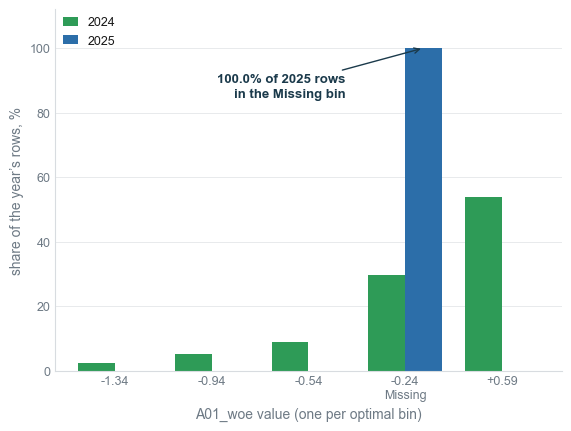

saved 05_a01_regime_break.png


In [14]:
b24 = diag.loc[diag['year'] == 2024, 'A01_woe'].value_counts(normalize=True).sort_index() * 100
b25 = diag.loc[diag['year'] == 2025, 'A01_woe'].value_counts(normalize=True).sort_index() * 100
comp = pd.DataFrame({'2024': b24, '2025': b25}).fillna(0.0)
missing = float(diag.loc[diag['A01'].isna(), 'A01_woe'].unique()[0])
x = np.arange(len(comp))
w = 0.38

fig, ax = plt.subplots(figsize=(5.6, 4.2), layout='constrained')
ax.bar(x - w / 2, comp['2024'], w, color=S1, lw=0, label='2024')
ax.bar(x + w / 2, comp['2025'], w, color=S2, lw=0, label='2025')
labels = [f'{v:+.2f}' + ('\nMissing' if abs(v - missing) < 1e-9 else '') for v in comp.index]
ax.set_xticks(x, labels, fontsize=8.5)
miss_i = int(np.argmin(np.abs(comp.index.to_numpy() - missing)))
ax.annotate('100.0% of 2025 rows\nin the Missing bin',
            xy=(miss_i + w / 2, 100), xytext=(miss_i - 0.62, 88),
            color=NAVY, fontsize=9.5, fontweight='bold', ha='right', va='center',
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.0))
ax.set_xlabel('A01_woe value (one per optimal bin)')
ax.set_ylabel('share of the year\u2019s rows, %')
ax.set_ylim(0, 112)
ax.legend(loc='upper left', handlelength=1.2, borderaxespad=0.2)
style(ax)
save(fig, '05_a01_regime_break')

### `05_seasonality` - the semester reset in E01

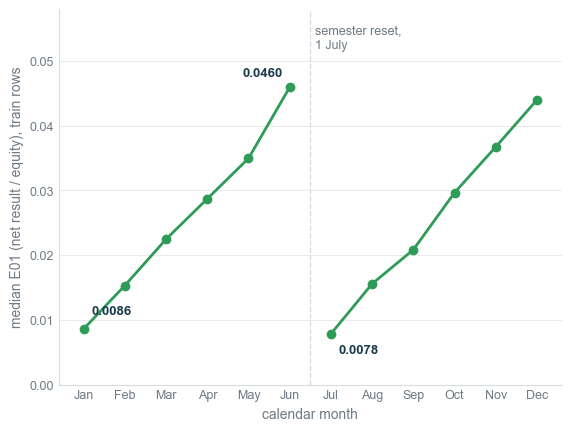

saved 05_seasonality.png


In [15]:
t = diag[diag['sample'] == 'train']
med = t.groupby('month')['E01'].median().reindex(range(1, 13))
months = list(range(1, 13))
names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(5.6, 4.2), layout='constrained')
ax.plot(months[:6], med.loc[1:6], color=S1, lw=2.0, marker='o', ms=6)
ax.plot(months[6:], med.loc[7:12], color=S1, lw=2.0, marker='o', ms=6)
ax.axvline(6.5, color=GREY_LINE, ls='--', lw=1.0)
ax.text(6.62, 0.0555, 'semester reset,\n1 July', color=GREY, fontsize=9, va='top')

for m, dx, dy, ha, va in ((1, 0.18, 0.0018, 'left', 'bottom'),
                          (6, -0.18, 0.0012, 'right', 'bottom'),
                          (7, 0.18, -0.0016, 'left', 'top')):
    ax.text(m + dx, med.loc[m] + dy, f'{med.loc[m]:.4f}', color=NAVY, fontsize=9.5,
            fontweight='bold', ha=ha, va=va)

ax.set_xticks(months, names)
ax.set_xlim(0.4, 12.6)
ax.set_ylim(0, 0.058)
ax.set_xlabel('calendar month')
ax.set_ylabel('median E01 (net result / equity), train rows')
style(ax)
save(fig, '05_seasonality')

## 4. Macro figures

Four more, built around the Point-in-Time overlay that notebook 04 tested and then withdrew. The
three BCB SGS series (4189 SELIC, 433 IPCA, 24363 IBC-Br) are cached at `Output/macro_sgs.parquet`
after the first fetch, so re-running this doesn't hit the API.

In [16]:
import requests
from sklearn.metrics import roc_auc_score

MACRO = ['SELIC', 'IPCA_12m', 'IBC_yoy']
CACHE = DIR_OUT / 'macro_sgs.parquet'


def fetch_sgs(code, name, start='01/01/2016'):
    """One monthly BCB SGS series as (DATA, value). Raises on any failure, never silent."""
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{code}/dados'
    r = requests.get(url, params={'formato': 'json', 'dataInicial': start}, timeout=60)
    r.raise_for_status()
    payload = r.json()
    if not isinstance(payload, list):
        raise RuntimeError(f'SGS {code} did not return a series: {payload!r:.200}')
    df = pd.DataFrame(payload)
    df['DATA'] = pd.to_datetime(df['data'], dayfirst=True).dt.strftime('%Y%m').astype(int)
    df[name] = df['valor'].astype(float)
    return df[['DATA', name]]


def month_axis(d):
    return pd.to_datetime(d.astype(str), format='%Y%m')


if CACHE.exists():
    macro = pd.read_parquet(CACHE)
else:
    macro = (fetch_sgs(4189, 'SELIC')
             .merge(fetch_sgs(433, 'IPCA'), on='DATA')
             .merge(fetch_sgs(24363, 'IBC'), on='DATA')
             .sort_values('DATA').reset_index(drop=True))
    macro['IPCA_12m'] = macro['IPCA'].rolling(12).sum()
    macro['IBC_yoy'] = macro['IBC'].pct_change(12) * 100
    macro.to_parquet(CACHE, index=False)
print(f'macro series: {macro["DATA"].min()} to {macro["DATA"].max()}, {len(macro)} months')

macro_metrics = mc.parse('macro_metrics').set_index('model')

panel = lab.merge(macro[['DATA'] + MACRO], on='DATA', how='left')
assert panel[MACRO].notna().all(axis=1).all(), 'macro coverage is not 100%'
train_m = panel[panel['sample'] == 'train']
oot_m = panel[panel['sample'] == 'oot']
assert len(train_m) == 7975 and len(oot_m) == 1737

oot_selic = sorted(oot_m['SELIC'].unique())
assert len(oot_selic) == 6, oot_selic

macro series: 201601 to 202606, 126 months


### `04_macro_series` - SELIC, IPCA and IBC-Br over the full panel

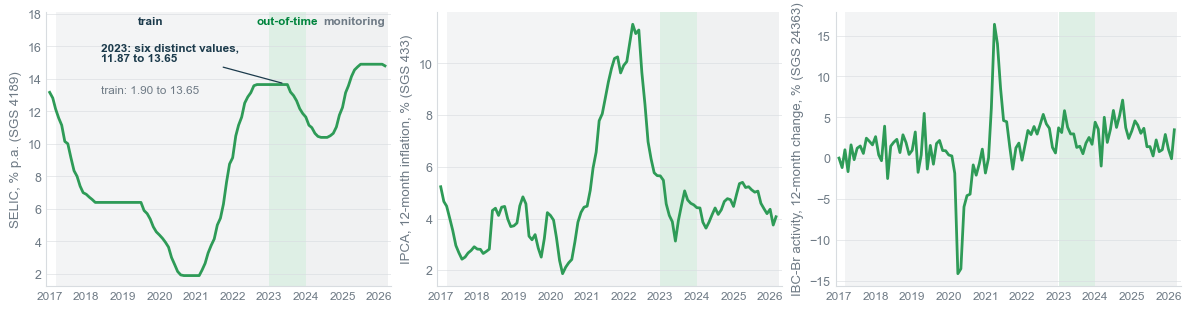

saved 04_macro_series.png


In [17]:
m = macro[(macro['DATA'] >= 201701) & (macro['DATA'] <= 202603)].copy()
x = month_axis(m['DATA'])
spans = [('train', 201703, 202212, NAVY, 0.05),
         ('out-of-time', 202301, 202312, GREEN, 0.13),
         ('monitoring', 202401, 202603, GREY, 0.10)]
panels = [('SELIC', 'SELIC, % p.a. (SGS 4189)'),
          ('IPCA_12m', 'IPCA, 12-month inflation, % (SGS 433)'),
          ('IBC_yoy', 'IBC-Br activity, 12-month change, % (SGS 24363)')]
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.0), layout='constrained')
for ax, (col, label) in zip(axes, panels):
    for name, a, b, colour, alpha in spans:
        ax.axvspan(month_axis(pd.Series([a]))[0], month_axis(pd.Series([b]))[0]
                   + pd.offsets.MonthEnd(0), color=colour, alpha=alpha, lw=0, zorder=0)
    ax.plot(x, m[col], color=S1, lw=2.0, zorder=3)
    ax.set_ylabel(label, fontsize=9.5)
    style(ax)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.margins(x=0.01)
# span labels once, on the first panel
ax = axes[0]
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], ylim[1] + 0.18 * (ylim[1] - ylim[0]))
top = ax.get_ylim()[1]
for name, a, b, colour, _, xpos, ha in [
        ('train', 201703, 202212, NAVY, 0, 201910, 'center'),
        ('out-of-time', 202301, 202312, GREEN, 0, 202307, 'center'),
        ('monitoring', 202401, 202603, GREY, 0, 202603, 'right')]:
    ax.text(month_axis(pd.Series([xpos]))[0], top * 0.985, name, color=colour,
            fontsize=8.5, ha=ha, va='top', fontweight='bold')
# the identification caveat, drawn on the SELIC panel
lo, hi = min(oot_selic), max(oot_selic)
ax.annotate(f'2023: six distinct values,\n{lo:.2f} to {hi:.2f}',
            xy=(month_axis(pd.Series([202307]))[0], hi),
            xytext=(month_axis(pd.Series([201806]))[0], 15.6),
            color=NAVY, fontsize=8.5, fontweight='bold', ha='left', va='center',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.9, shrinkA=2, shrinkB=4))
ax.text(month_axis(pd.Series([201806]))[0], 13.3, 'train: 1.90 to 13.65', color=GREY,
        fontsize=8.5, ha='left', va='center')
save(fig, '04_macro_series')

### `04_macro_gain` - AUC gain from adding macro

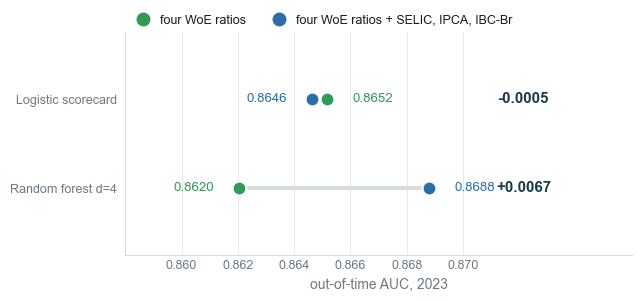

saved 04_macro_gain.png


In [18]:
rows = [('Logistic scorecard', 'Logit WoE (baseline)', 'Logit WoE + macro'),
        ('Random forest d=4', 'Forest WoE d=4', 'Forest WoE + macro d=4')]
fig, ax = plt.subplots(figsize=(6.3, 2.9), layout='constrained')
y = np.arange(len(rows))[::-1]
for yi, (label, base, plus) in zip(y, rows):
    a = float(macro_metrics.loc[base, 'oot_AUC'])
    b = float(macro_metrics.loc[plus, 'oot_AUC'])
    ax.plot([a, b], [yi, yi], color=GREY_LINE, lw=3.0, solid_capstyle='round', zorder=2)
    ax.plot([a], [yi], marker='o', ms=10, color=S1, zorder=4, mec=WHITE, mew=1.5)
    ax.plot([b], [yi], marker='o', ms=10, color=S2, zorder=5, mec=WHITE, mew=1.5)
    lo_v, lo_c = (a, S1) if a <= b else (b, S2)
    hi_v, hi_c = (b, S2) if a <= b else (a, S1)
    ax.text(lo_v - 0.0009, yi, f'{lo_v:.4f}', color=lo_c, fontsize=9.5, ha='right',
            va='center')
    ax.text(hi_v + 0.0009, yi, f'{hi_v:.4f}', color=hi_c, fontsize=9.5, ha='left',
            va='center')
    d = b - a
    ax.text(0.8712, yi, f'{d:+.4f}', color=NAVY, fontsize=11, fontweight='bold',
            ha='left', va='center')
ax.plot([], [], marker='o', ms=9, color=S1, lw=0, label='four WoE ratios')
ax.plot([], [], marker='o', ms=9, color=S2, lw=0, label='four WoE ratios + SELIC, IPCA, IBC-Br')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.10), ncols=2, handletextpad=0.4,
          columnspacing=1.6, borderaxespad=0.0)
ax.set_yticks(y)
ax.set_yticklabels([r[0] for r in rows], fontsize=10, color=INK)
ax.set_ylim(-0.75, len(rows) - 0.25)
ax.set_xlim(0.8580, 0.8760)
ax.set_xticks([0.860, 0.862, 0.864, 0.866, 0.868, 0.870])
ax.set_xlabel('out-of-time AUC, 2023')
style(ax, ygrid=False, xgrid=True)
ax.tick_params(axis='y', pad=6)
save(fig, '04_macro_gain')

### Refitting the forest with macro

Same rule as the tree and the SHAP forest above: refit on `train_m`, then assert the out-of-time
AUC matches what's published before drawing anything from it.

In [19]:
rf_macro = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=20,
                                  class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_macro.fit(train_m[FEATURES + MACRO], train_m['y_adj'])
auc = roc_auc_score(oot_m['y_adj'], rf_macro.predict_proba(oot_m[FEATURES + MACRO])[:, 1])
published = float(macro_metrics.loc['Forest WoE + macro d=4', 'oot_AUC'])
print(f'forest + macro refit: oot AUC {auc:.4f} (published {published:.4f})')
assert abs(auc - published) < 5e-4, (auc, published)

forest + macro refit: oot AUC 0.8688 (published 0.8688)


### `04_macro_importance` - split importance, forest + macro

importances: A01_woe 0.222, M01_woe 0.123, E01_woe 0.503, L01_woe 0.092, SELIC 0.027, IPCA_12m 0.021, IBC_yoy 0.013
macro share: 6.1%


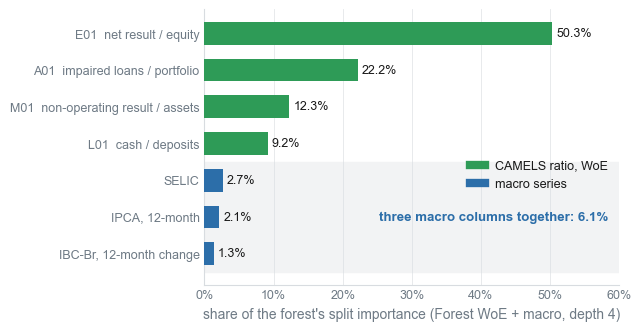

saved 04_macro_importance.png


In [20]:
imp = pd.Series(rf_macro.feature_importances_, index=FEATURES + MACRO)
print('importances:', ', '.join(f'{k} {v:.3f}' for k, v in imp.items()))
print(f'macro share: {imp[MACRO].sum():.1%}')
imp = imp.sort_values()
pretty = {'A01_woe': 'A01  impaired loans / portfolio',
          'M01_woe': 'M01  non-operating result / assets',
          'E01_woe': 'E01  net result / equity',
          'L01_woe': 'L01  cash / deposits',
          'SELIC': 'SELIC', 'IPCA_12m': 'IPCA, 12-month', 'IBC_yoy': 'IBC-Br, 12-month change'}
colours = [S2 if k in MACRO else S1 for k in imp.index]
fig, ax = plt.subplots(figsize=(6.3, 3.2), layout='constrained')
y = np.arange(len(imp))
ax.barh(y, imp.values, color=colours, height=0.62, zorder=3)
for yi, v in zip(y, imp.values):
    ax.text(v + 0.006, yi, f'{v:.1%}', color=INK, fontsize=9, va='center', ha='left')
ax.set_yticks(y)
ax.set_yticklabels([pretty[k] for k in imp.index], fontsize=9.5, color=INK)
ax.set_xlim(0, 0.60)
ax.set_xlabel('share of the forest\'s split importance (Forest WoE + macro, depth 4)')
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
macro_share = imp[MACRO].sum()
ax.axhspan(-0.5, 2.5, color=GREY_FILL, zorder=0)
ax.text(0.585, 1.0, f'three macro columns together: {macro_share:.1%}', color=S2,
        fontsize=9.5, fontweight='bold', ha='right', va='center')
ax.plot([], [], color=S1, lw=6, label='CAMELS ratio, WoE')
ax.plot([], [], color=S2, lw=6, label='macro series')
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.30), handlelength=1.2)
style(ax, ygrid=False, xgrid=True)
save(fig, '04_macro_importance')

### `04_shap_macro` - SHAP with macro in the mix

mean |SHAP| : E01_woe 0.1223, A01_woe 0.0640, M01_woe 0.0367, L01_woe 0.0293, SELIC 0.0093, IPCA_12m 0.0043, IBC_yoy 0.0023


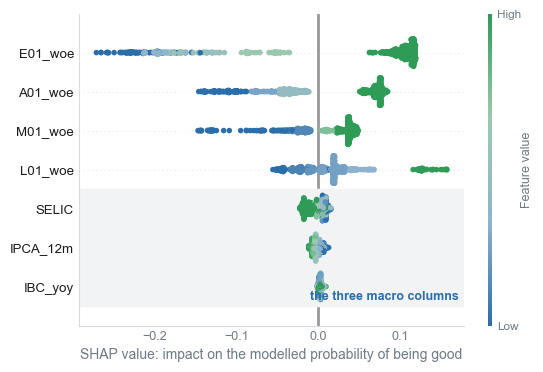

saved 04_shap_macro.png


In [21]:
import shap

sample = oot_m[FEATURES + MACRO].sample(n=800, random_state=SEED)
explainer = shap.TreeExplainer(rf_macro)
sv = explainer(sample, check_additivity=False)[..., 1]
mean_abs = pd.Series(np.abs(sv.values).mean(axis=0),
                     index=FEATURES + MACRO).sort_values(ascending=False)
print('mean |SHAP| :', ', '.join(f'{k} {v:.4f}' for k, v in mean_abs.items()))

cmap = LinearSegmentedColormap.from_list('cr_blue_green', [S2, '#8FB3CE', '#9CCAAE', S1])
fig = plt.figure(figsize=(6.6, 3.9))
shap.plots.beeswarm(sv, show=False, color=cmap, color_bar=True, plot_size=None,
                    max_display=7)
ax = plt.gca()
ax.set_title('')
ax.set_xlabel('SHAP value: impact on the modelled probability of being good', fontsize=10,
              color=GREY)
ax.set_ylabel('')
style(ax, ygrid=False)
ax.grid(False)
ax.tick_params(axis='y', labelsize=9.5, colors=INK, length=0)
# shade the three macro rows so the eye finds them
ylab = [t.get_text() for t in ax.get_yticklabels()]
ticks = ax.get_yticks()
macro_ticks = [ticks[i] for i, t in enumerate(ylab) if t in MACRO]
if macro_ticks:
    ax.axhspan(min(macro_ticks) - 0.5, max(macro_ticks) + 0.5, color=GREY_FILL, zorder=0)
    ax.text(0.985, min(macro_ticks) - 0.5 + 0.10, 'the three macro columns',
            transform=ax.get_yaxis_transform(), color=S2, fontsize=9, fontweight='bold',
            ha='right', va='bottom')
for cb_ax in fig.axes[1:]:
    cb_ax.tick_params(length=0, colors=GREY, labelsize=8.5)
    for spine in cb_ax.spines.values():
        spine.set_visible(False)
    cb_ax.set_ylabel(cb_ax.get_ylabel(), color=GREY, fontsize=9)
fig.subplots_adjust(left=0.17, right=0.90, top=0.97, bottom=0.17)
save(fig, '04_shap_macro')
assert mean_abs.index[0] == 'E01_woe'
assert set(mean_abs.index[-3:]) == set(MACRO), mean_abs

All seventeen figures are on disk in `figures/` at dpi 200, matching what's in the deck.